## Dataanalysis

In [5]:
import matplotlib.pyplot as plt
import os


def save_plot_to_thesis_dir(figure, filename):
    thesis_img_dir = os.path.join("..", "..", "tex", "thesis", "img")

    if not os.path.exists(thesis_img_dir):
        raise FileNotFoundError(f'the given directory {thesis_img_dir} does not exist')

    file_path = os.path.join(thesis_img_dir, filename)

    figure.savefig(file_path)
    print(f"Plot saved to {file_path}")

In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt


df = pd.read_csv(
    "../../data/linter-results/2024-09-14@81c1e820ca6c67f61e69525e4e35cb3cf1f0778b.csv",
    delimiter=";", index_col="specs"
)

with open("config/ruleconfig.json", "r") as file:
    ruleconfig = json.load(file)

onlySingleTriggerColumns = [
    rule for rule in ruleconfig.keys() if ruleconfig[rule]["status"] == "SINGLE_TRIGGER"
]

df_only_single = df[onlySingleTriggerColumns]

def map_to_total_thrown(inversion: str) -> int :
    inversion =  json.loads(inversion)
    thrownMessages = inversion['thrownMessages']
    return thrownMessages 

df_transformed = pd.DataFrame.map(df_only_single, map_to_total_thrown)

In [7]:
pd.DataFrame.mean(df_transformed)

contact-properties             0.000000
info-contact                   0.570358
info-description               0.117021
info-license                   0.000000
license-url                    0.000000
openapi-tags-alphabetical      0.000000
oas3-api-servers               0.010880
oas3-server-not-example.com    0.000000
dtype: float64

In [8]:
onlyMultiTriggerColumns = [
    rule
    for rule in ruleconfig.keys()
    if (ruleconfig[rule]["status"] == "MULTI_TRIGGER")
    and rule
    not in [
        "operation-tag-defined",
        "path-keys-no-trailing-slash",
        "typed-enum",
        "oas3-unused-component",
        "path-not-include-query",
        "oas3-valid-media-example",
        "oas3-valid-schema-example",
        "oas3-schema",
        "oas3-callbacks-in-callbacks",
        "no-$ref-siblings",
    ]
]

df_only_multi = df[onlyMultiTriggerColumns]


def map_to_total_thrown(inversion: str) -> int:
    inversion = json.loads(inversion)
    thrownMessages = inversion["thrownMessages"]
    return thrownMessages 


def map_to_total_possible(inversion: str) -> int:
    inversion = json.loads(inversion)
    possibleMessages = inversion["possibleMessages"]
    return possibleMessages


df_transformed_thrown = pd.DataFrame.map(df_only_multi, map_to_total_thrown)
df_transformed_possible = pd.DataFrame.map(df_only_multi, map_to_total_possible)

In [9]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))
bar_width = 0.3
index = np.arange(len(df_transformed_possible.columns))

ax.bar(
    index - bar_width / 2, pd.DataFrame.mean(df_transformed_thrown).values, bar_width-0.05, label='geworfene Linterfehler'
)
ax.bar(
    index + bar_width / 2, pd.DataFrame.mean(df_transformed_possible).values, bar_width-0.05, label='mögliche Linterfehler'
)
ax.set_xticks(index)
ax.set_xticklabels(df_transformed_thrown.columns, rotation=45, ha="right")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Linterregeln")
ax.set_ylabel("Arithmetisches Mittel Linterfehler")
ax.legend()
ax.set_title("Multi Trigger Säulendiagramm")
fig.tight_layout()
save_plot_to_thesis_dir(figure=fig, filename="multitriggerbarplot")
plt.close("all")

Plot saved to ../../tex/thesis/img/multitriggerbarplot


In [10]:
import pandas as pd
import json
import matplotlib.pyplot as plt


df = pd.read_csv(
    "../../data/linter-results/2024-09-14@81c1e820ca6c67f61e69525e4e35cb3cf1f0778b.csv",
    delimiter=";",
    index_col="specs",
)

with open("config/ruleconfig.json", "r") as file:
    ruleconfig = json.load(file)

no_oas2_rules = [
    rule for rule in ruleconfig.keys() if ruleconfig[rule]["status"] != "OPENAPI_2_X"
]

df_no_oas2_rules = df[no_oas2_rules]


def map_to_was_thrown(inversion: str) -> int:
    inversion = json.loads(inversion)
    if inversion["thrownMessages"] > 0:
        return 1
    else:
        return 0

df_transformed = pd.DataFrame.map(df_no_oas2_rules, map_to_was_thrown)

In [11]:
fig, ax = plt.subplots(figsize=(15, 10))
ax.bar(df_transformed.columns, pd.DataFrame.sum(df_transformed), 0.5, label="Linterfehler")
ax.set_xticklabels(df_transformed.columns, rotation=45, ha="right")
ax.grid(True, which="both", linestyle="--", linewidth=0.7)
ax.set_yscale("log")
ax.set_xlabel("Linterregeln")
ax.set_ylabel("Anzahl Spezifikationen")
ax.legend()
ax.set_title("Kumulativ Spezifikationen, die Linterfehler ausgelöst haben")
fig.tight_layout()
save_plot_to_thesis_dir(figure=fig, filename="totalspecthrownbarplot")
plt.close("all")

/tmp/ipykernel_192901/2128134425.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_transformed.columns, rotation=45, ha="right")


Plot saved to ../../tex/thesis/img/totalspecthrownbarplot


Plot saved to ../../tex/thesis/img/hierarchicalclusteronbinary


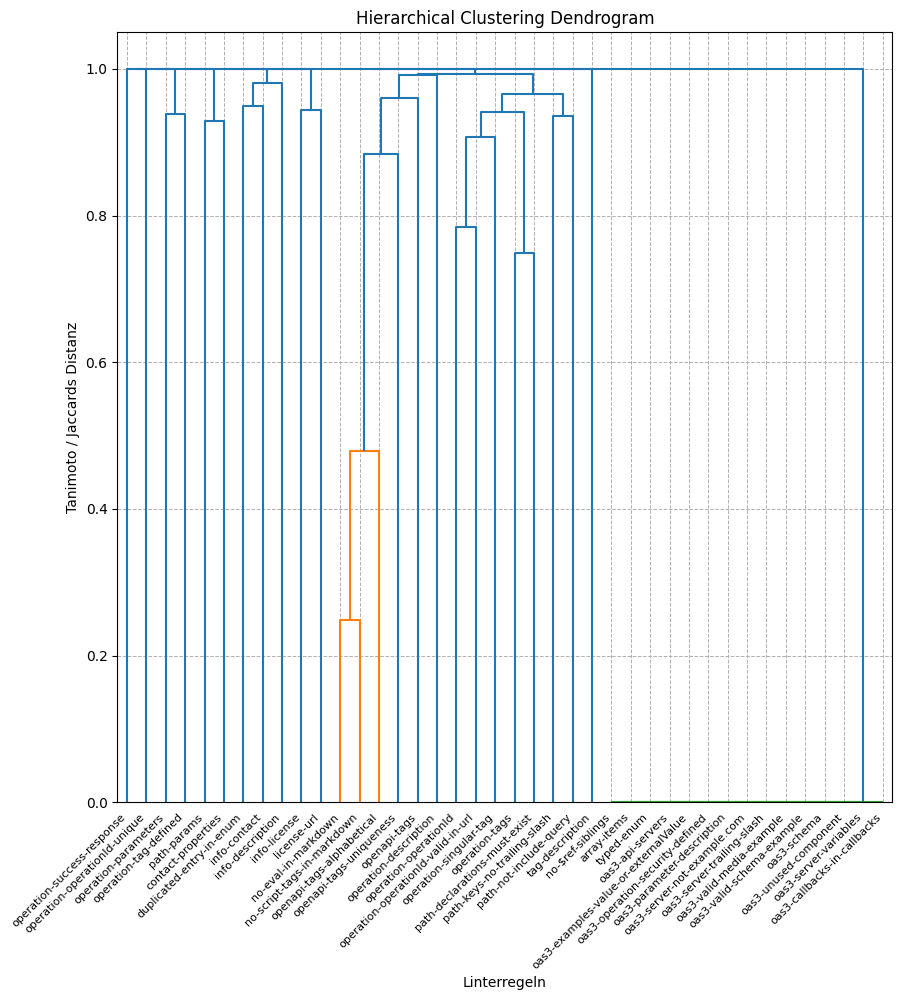

In [30]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage

distance_matrix = pdist(df_transformed.T, metric="jaccard")
linked = linkage(distance_matrix, method="complete")

fig, ax = plt.subplots(figsize=(10, 10))
dendrogram(
    linked,
    orientation="top",
    distance_sort="descending",
    show_leaf_counts=True,
    labels=df_transformed.columns,
    ax=ax
)
ax.set_xticklabels(df_transformed.columns, rotation=45, ha="right")
ax.grid(True, which="both", linestyle="--", linewidth=0.7)
ax.set_title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Linterregeln")
ax.set_ylabel("Tanimoto / Jaccards Distanz")
save_plot_to_thesis_dir(figure=fig, filename="hierarchicalclusteronbinary")
plt.close("all")